In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from linearreg import *


In [2]:
path = "./house_prices.csv"
data = pd.read_csv(path)

features = ["sqft_living", "sqft_lot", "floors", "bedrooms", "bathrooms"]

target = ["price"]

X_train = data.loc[:, features]
y_true = data.loc[:, target]

X_train, Xmean, Xstd = zscore_normalize(X_train.to_numpy())
y_true, ymean, ystd = zscore_normalize(y_true.to_numpy()); y_true = y_true.ravel()

In [3]:
w_init = np.zeros(X_train.shape[1])
b_init = 0
print(w_init, b_init)

[0. 0. 0. 0. 0.] 0


In [4]:
w, b, J_his, w_his, b_his = optimize_parameters(X_train, y_true, w_init, b_init, 100_000, 3e-5)
print(w, b)

Iteration 0: cost 0.5
Iteration 10000: cost 0.34831889301839103
Iteration 20000: cost 0.30621791012866456
Iteration 30000: cost 0.29016025799287964
Iteration 40000: cost 0.28119389198235273
Iteration 50000: cost 0.27482860689405036
Iteration 60000: cost 0.2698551753941882
Iteration 70000: cost 0.2658409543445611
Iteration 80000: cost 0.2625613726754481
Iteration 90000: cost 0.2598652660823836
[ 0.5413192  -0.00452     0.00957534 -0.04802574  0.15819252] -1.0187845446887919e-16


In [5]:
w_his = w_his[::100]
b_his = b_his[::100]
J_his = J_his[::100]

print(*[len(item) for item in (w_his, b_his, J_his)])


1000 1000 1000


In [6]:
J_his = np.array(J_his)
w_his = np.array(w_his)
print(J_his.shape)	#loss of 21613 samples at timestep t with 1000 various timesteps
J_his = np.sum(J_his, axis=1)
print(J_his.shape)	#total loss at timestep t with 1000 various timesteps


(1000, 21613)
(1000,)


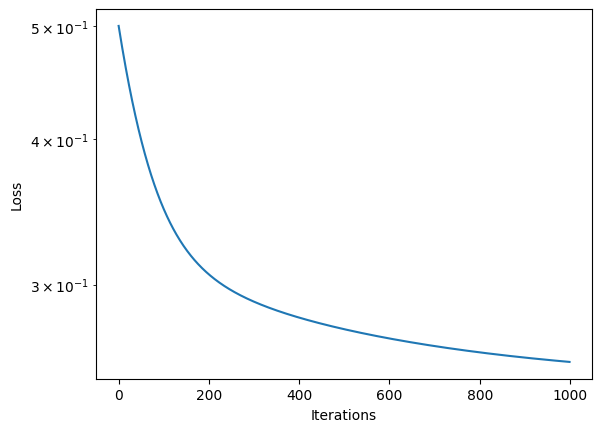

In [7]:
#Loss vs iterations
#Gradient work just as he need to, converged
iterations = np.arange(len(J_his))

plt.plot(iterations, J_his)
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

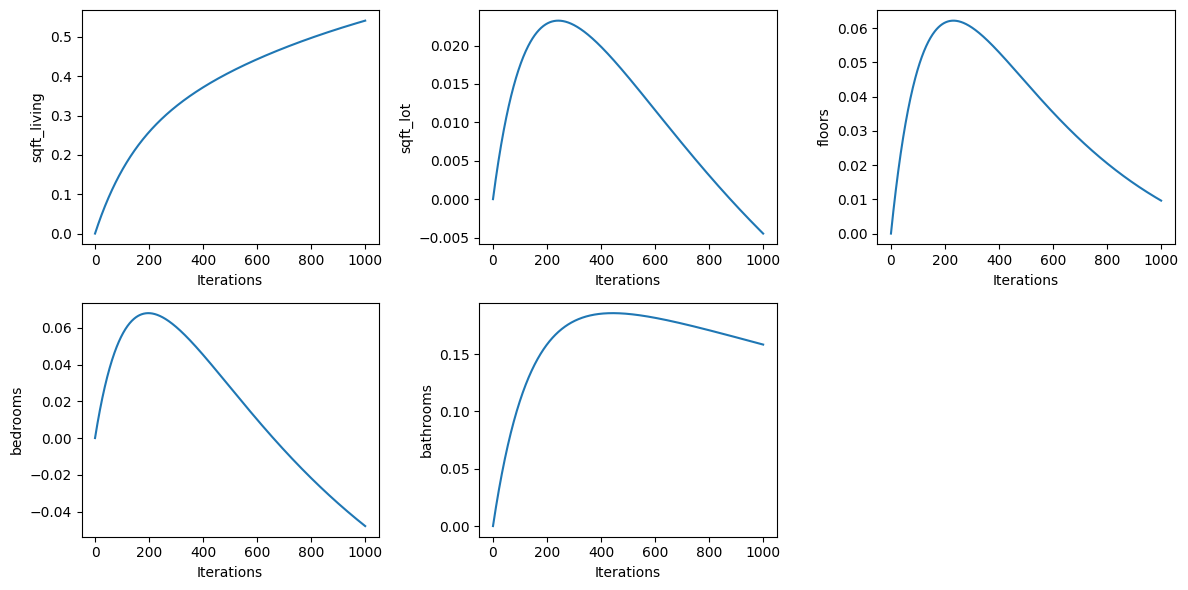

In [8]:
#Weights vs Iterations, bias optimal value is very close to 0(because of zscore normalization), so we wont plot him
#We can see that almost all features jumps over their minimun, so we are gonna reduce learning rate and do fitting again
n_features = len(features) - 1
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for weight_idx, ax in enumerate(axes.flat):
    if weight_idx > n_features:
        ax.set_visible(False)
        continue

    ax.plot(iterations, w_his[:, weight_idx])
    ax.set_xlabel("Iterations")
    ax.set_ylabel(features[weight_idx])

fig.tight_layout()
plt.show()

In [9]:
#Predictions
X_sample_idxs = np.random.choice(len(X_train), 10)
X_sample = X_train[X_sample_idxs, :]

y_pred_norm = f(X_sample, w, b)
y_pred_sample = inverse_transform(y_pred_norm, ymean, ystd)
y_true_sample = inverse_transform(y_true[X_sample_idxs], ymean, ystd)
for idx in range(len(y_pred_sample)):
    print(f"True value: {y_true_sample[idx]}$, Predicted value: {y_pred_sample[idx]:.0f}$, Difference: {abs(y_true_sample[idx] - y_pred_sample[idx]):.0f}$")

True value: 350000.0$, Predicted value: 228487$, Difference: 121513$
True value: 480500.0$, Predicted value: 575810$, Difference: 95310$
True value: 465000.0$, Predicted value: 556396$, Difference: 91396$
True value: 530000.0$, Predicted value: 300172$, Difference: 229828$
True value: 485000.0$, Predicted value: 496531$, Difference: 11531$
True value: 575000.0$, Predicted value: 829741$, Difference: 254741$
True value: 550000.0$, Predicted value: 525535$, Difference: 24465$
True value: 706000.0$, Predicted value: 813613$, Difference: 107613$
True value: 585000.0$, Predicted value: 586732$, Difference: 1732$
True value: 350000.0$, Predicted value: 346055$, Difference: 3945$
